In [29]:

data = {
    "Study_Hours": [
        "High", "High", "Medium", "Low", "High",
        "Medium", "Low", "High", "Low", "Medium",
        "High", "Low", "Medium", "High", "Low",
        "Medium", "High", "Low", "Medium", "High"
    ],

    "Attendance": [
        "Good", "Poor", "Good", "Poor", "Good",
        "Good", "Poor", "Good", "Good", "Poor",
        "Poor", "Good", "Poor", "Good", "Poor",
        "Good", "Good", "Poor", "Good", "Poor"
    ],

    "Assignment": [
        "Yes", "Yes", "Yes", "No", "Yes",
        "No", "No", "Yes", "Yes", "No",
        "Yes", "No", "Yes", "Yes", "No",
        "Yes", "Yes", "No", "Yes", "Yes"
    ],

    "Previous_Result": [
        "Pass", "Pass", "Pass", "Fail", "Pass",
        "Pass", "Fail", "Pass", "Pass", "Fail",
        "Pass", "Fail", "Pass", "Pass", "Fail",
        "Pass", "Pass", "Fail", "Pass", "Pass"
    ],

    "Pass": [
        "Yes", "Yes", "Yes", "No", "Yes",
        "Yes", "No", "Yes", "No", "No",
        "Yes", "No", "Yes", "Yes", "No",
        "Yes", "Yes", "No", "Yes", "Yes"
    ]
}

df = pd.DataFrame(data)

df


,Study_Hours,Attendance,Assignment,Previous_Result,Pass
0,High,Good,Yes,Pass,Yes
1,High,Poor,Yes,Pass,Yes
2,Medium,Good,Yes,Pass,Yes
3,Low,Poor,No,Fail,No
4,High,Good,Yes,Pass,Yes
5,Medium,Good,No,Pass,Yes
6,Low,Poor,No,Fail,No
7,High,Good,Yes,Pass,Yes
8,Low,Good,Yes,Pass,No
9,Medium,Poor,No,Fail,No


In [5]:
df.to_csv("student_pass_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [6]:
df.head()

,Study_Hours,Attendance,Assignment,Previous_Result,Pass
0,High,Good,Yes,Pass,Yes
1,High,Poor,Yes,Pass,Yes
2,Medium,Good,Yes,Pass,Yes
3,Low,Poor,No,Fail,No
4,High,Good,Yes,Pass,Yes


In [8]:
df.shape

(20, 5)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Study_Hours      20 non-null     object
 1   Attendance       20 non-null     object
 2   Assignment       20 non-null     object
 3   Previous_Result  20 non-null     object
 4   Pass             20 non-null     object
dtypes: object(5)
memory usage: 932.0+ bytes


In [30]:
df.isnull().sum()

Study_Hours        0
Attendance         0
Assignment         0
Previous_Result    0
Pass               0
dtype: int64

,Study_Hours,Attendance,Assignment,Previous_Result,Pass
count,20,20,20,20,20
unique,3,2,2,2,2
top,High,Good,Yes,Pass,Yes
freq,8,11,13,14,13


In [15]:
df['Pass'].value_counts()

Pass
Yes    13
No      7
Name: count, dtype: int64

In [18]:
df.describe(include="all")

,Study_Hours,Attendance,Assignment,Previous_Result,Pass
count,20,20,20,20,20
unique,3,2,2,2,2
top,High,Good,Yes,Pass,Yes
freq,8,11,13,14,13


In [33]:
df["Study_Hours"] = df["Study_Hours"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

df["Attendance"] = df["Attendance"].map({
    "Poor": 0,
    "Good": 1
})

df["Assignment"] = df["Assignment"].map({
    "No": 0,
    "Yes": 1
})

df["Previous_Result"] = df["Previous_Result"].map({
    "Fail": 0,
    "Pass": 1
})

df["Pass"] = df["Pass"].map({
    "No": 0,
    "Yes": 1
})

In [34]:
df.head()

,Study_Hours,Attendance,Assignment,Previous_Result,Pass
0,2,1,1,1,1
1,2,0,1,1,1
2,1,1,1,1,1
3,0,0,0,0,0
4,2,1,1,1,1


In [35]:
# # Study_Hours	Attendance	Assignment	Previous_Result	Pass
# print(df["Study_Hours"].unique())
# print(df["Attendance"].unique())
# print(df["Assignment"].unique())
# print(df["Previous_Result"].unique())
# print(df["Pass"].unique())


In [39]:
# Feature Selection (X and y)
# features(Input)
X = df.drop("Pass", axis=1)

# Target(output)
y = df["Pass"]


In [40]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



In [41]:
# Check Testing Data
print(X_test.shape)
print(y_test.shape)

(4, 4)
(4,)


In [42]:
# Train the Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

# Create the model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [44]:
# Make predictions on test data
y_pred = model.predict(X_test)
# print prediction
print("Predicted Values:")
print(y_pred)

Predicted Values:
[1 0 1 1]


In [45]:
# Compare Actual vs Predicted
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,1,1
17,0,0
15,1,1
1,1,1


In [46]:
# Evaluate the Model

# Accuracy Score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 1.0


In [47]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1 0]
 [0 3]]


In [48]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



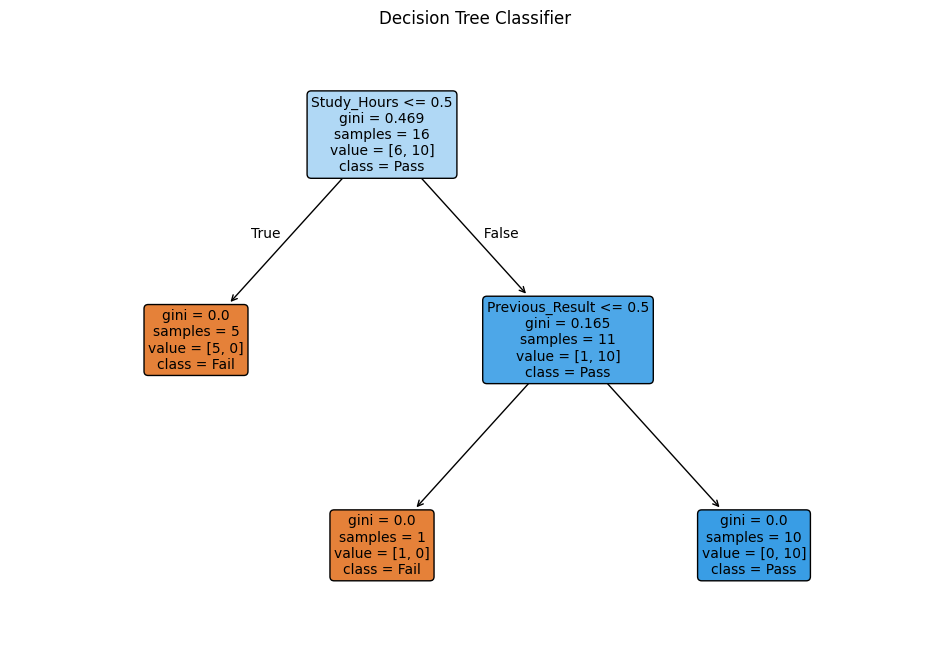

In [49]:
# Visualize the Decision Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Classifier")
plt.show()

